# 03 - Riesgo por repositorio y conclusiones

## Introducción
Notebook de cierre orientado a priorización: valida el consolidado, compara señales de riesgo y sintetiza conclusiones para reporte.

## Pregunta que responde
**¿Qué repositorios concentran mayor riesgo relativo y cómo justificar técnicamente esa priorización?**

### Cómo interpretar esta sección
- Se valida contrato mínimo de `analysis.json`.
- Se comparan fuentes (Grype, CodeQL y CI/CD) por repositorio.
- Se usa ranking por `risk_score` para priorización operativa.

### Por qué importa en ciberseguridad
La priorización basada en evidencia reduce decisiones subjetivas y permite planificar mitigación con criterio reproducible.


## Generación y validación del dataset consolidado

`analyzer/generate_analysis.py` es el motor que construye `analysis.json` desde artefactos raw.
Este notebook lo ejecuta en modo seguro (`--skip-notebooks`) y valida que el contrato mínimo esté presente.

### Diferencia entre `risk_score_raw` y `risk_score`
- **`risk_score_raw`**: puntaje híbrido que combina tres señales: Grype (60%), CodeQL (20%) y CI/CD (20%). El componente Grype usa el promedio ponderado de `risk × severity_weight` por vulnerabilidad. CodeQL y CI/CD usan escala logarítmica para evitar dominancia.
- **`risk_score`**: versión clampada a máximo 10 para comparar repositorios en una misma escala.

### Fórmula del risk score
- **Grype (60%)**: `Σ(vuln.risk × severity_weight) / max(vuln_count, 1)` donde severity_weight: Critical=4, High=3, Medium=2, Low=1.
- **CodeQL (20%)**: `min(log1p(codeql_issues) × 2, 10)` — escala logarítmica para saturar naturalmente.
- **CI/CD (20%)**: `min(log1p(cicd_findings) × 3, 10)` — escala logarítmica para saturar naturalmente.
- **Final**: `grype×0.6 + codeql×0.2 + cicd×0.2`, clampado a 10.

### `vulnerability_density`
Representa vulnerabilidades por cada 100 componentes, útil para medir concentración de exposición relativa.

### Por qué comparar Grype vs CodeQL vs CI/CD
- **Grype**: exposición en dependencias/componentes (vulnerabilidades conocidas con CVE).
- **CodeQL**: debilidades en código fuente (patrones de riesgo detectados por SAST).
- **CI/CD**: riesgos operativos en automatización (permisos excesivos, prácticas inseguras).

Juntas, estas fuentes ofrecen cobertura complementaria del riesgo. El risk score las integra en un solo indicador priorizando Grype como la señal más accionable.


In [1]:
from __future__ import annotations

import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'analyzer' / 'generate_analysis.py').exists():
            return candidate
    return Path.cwd()


root = find_project_root()
generator = root / 'analyzer' / 'generate_analysis.py'
analysis_path = root / 'data' / 'results' / 'analysis.json'

result = subprocess.run(
    ['python3', str(generator), '--skip-notebooks'],
    cwd=str(root),
    capture_output=True,
    text=True,
    check=False,
)

print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError('Falló la generación de analysis.json con --skip-notebooks')

assert analysis_path.exists(), f'No existe archivo consolidado: {analysis_path}'
analysis = json.loads(analysis_path.read_text(encoding='utf-8'))

print(f'analysis.json actualizado en: {analysis_path}')

Analysis generated at: /home/leocast/Desktop/Ciberseguridad/Proyecto/data/results/analysis.json
Analysis unchanged. Skipping notebook execution.

analysis.json actualizado en: /home/leocast/Desktop/Ciberseguridad/Proyecto/data/results/analysis.json


## Verificación de señales raw para cierre

Antes de concluir el ranking, se contrasta una evidencia mínima de datos raw (riesgo Grype, issues CodeQL y findings CI/CD) para mantener trazabilidad desde fuente.


In [2]:
raw_signal_rows = []
for path in sorted((root / 'data' / 'results' / 'vulns').glob('*_vuln.json')):
    data = json.loads(path.read_text(encoding='utf-8'))
    risks = []
    for match in data.get('matches', []) if isinstance(data, dict) else []:
        vuln = match.get('vulnerability', {}) if isinstance(match, dict) else {}
        risk = vuln.get('risk')
        if isinstance(risk, (int, float)):
            risks.append(float(risk))
    raw_signal_rows.append({'repo': path.name.replace('_vuln.json',''), 'avg_grype_risk_raw': (sum(risks)/len(risks)) if risks else 0.0, 'vuln_items_raw': len(data.get('matches', [])) if isinstance(data, dict) and isinstance(data.get('matches'), list) else 0})

df_raw_signals = pd.DataFrame(raw_signal_rows)

codeql_counts = []
for path in sorted((root / 'data' / 'reports').glob('*_codeql.sarif')):
    data = json.loads(path.read_text(encoding='utf-8'))
    runs = data.get('runs', []) if isinstance(data, dict) else []
    first = runs[0] if isinstance(runs, list) and runs else {}
    results = first.get('results', []) if isinstance(first, dict) else []
    codeql_counts.append({'repo': path.name.replace('_codeql.sarif',''), 'codeql_raw': len(results) if isinstance(results, list) else 0})

cicd_counts = []
for path in sorted((root / 'data' / 'reports').glob('*_cicd.json')):
    data = json.loads(path.read_text(encoding='utf-8'))
    findings = data.get('findings', []) if isinstance(data, dict) else []
    cicd_counts.append({'repo': path.name.replace('_cicd.json',''), 'cicd_raw': len(findings) if isinstance(findings, list) else 0})

df_raw_crosscheck = df_raw_signals.merge(pd.DataFrame(codeql_counts), on='repo', how='left').merge(pd.DataFrame(cicd_counts), on='repo', how='left').fillna(0)
display(df_raw_crosscheck.sort_values('avg_grype_risk_raw', ascending=False))


,repo,avg_grype_risk_raw,vuln_items_raw,codeql_raw,cicd_raw
4,langsmith-java,0.200075,2,0.0,0
0,deepagents,0.003089,10,11.0,2
1,docs,0.000392,5,0.0,0
2,langchain,0.000000,1,13.0,2
3,langsmith-go,0.000000,0,0.0,0
5,streaming-cookbook,0.000000,4,0.0,0


In [3]:
# Validación de schema mínimo
assert 'metadata' in analysis, 'Falta metadata'
assert 'repositories' in analysis, 'Falta repositories'
assert 'cross_repo_analysis' in analysis, 'Falta cross_repo_analysis'

for repo in analysis.get('repositories', []) or []:
    metrics = repo.get('metrics', {}) or {}
    vulns = repo.get('vulnerabilities', {}) or {}
    codeql = repo.get('codeql', {}) or {}

    assert 'risk_score' in metrics, f"Falta metrics.risk_score en {repo.get('name')}"
    assert 'risk_score_raw' in metrics, f"Falta metrics.risk_score_raw en {repo.get('name')}"
    assert 'by_type' in vulns, f"Falta vulnerabilities.by_type en {repo.get('name')}"
    assert 'with_fix_available' in vulns, f"Falta vulnerabilities.with_fix_available en {repo.get('name')}"
    assert 'by_level' in codeql, f"Falta codeql.by_level en {repo.get('name')}"

assert 'common_weakness_ranking' in analysis.get('cross_repo_analysis', {}), 'Falta cross_repo_analysis.common_weakness_ranking'

print('Schema mínimo validado correctamente.')

Schema mínimo validado correctamente.


In [4]:
repo_rows = []
cicd_rows = []
for repo in analysis.get('repositories', []) or []:
    repo_rows.append({
        'name': repo.get('name', 'unknown'),
        'vulnerabilities': repo.get('vulnerabilities', {}).get('total', 0),
        'codeql_issues': repo.get('codeql', {}).get('total_issues', 0),
        'cicd_findings': repo.get('cicd', {}).get('total_findings', 0),
        'components': repo.get('sbom', {}).get('total_components', 0),
        'vulnerability_density': repo.get('metrics', {}).get('vulnerability_density', 0.0),
        'risk_score_raw': repo.get('metrics', {}).get('risk_score_raw', 0.0),
        'risk_score': repo.get('metrics', {}).get('risk_score', 0.0),
    })

    for finding in repo.get('cicd', {}).get('items', []) or []:
        cicd_rows.append({
            'repo': repo.get('name', 'unknown'),
            'workflow': finding.get('workflow', 'unknown'),
            'issue': finding.get('issue', 'unknown'),
        })

df_repo = pd.DataFrame(repo_rows)
df_cicd = pd.DataFrame(cicd_rows) if cicd_rows else pd.DataFrame(columns=['repo', 'workflow', 'issue'])

if df_repo.empty:
    df_repo = pd.DataFrame(columns=['name','vulnerabilities','codeql_issues','cicd_findings','components','vulnerability_density','risk_score_raw','risk_score'])

df_repo = df_repo.sort_values('risk_score', ascending=False).reset_index(drop=True)
df_repo

,name,vulnerabilities,codeql_issues,cicd_findings,components,vulnerability_density,risk_score_raw,risk_score
0,langsmith-java,2,0,0,14,14.285714,0.60,0.60
1,deepagents,10,11,2,2276,0.439367,0.01,0.01
2,docs,5,0,0,502,0.996016,0.00,0.00
3,langchain,1,13,2,2330,0.042918,0.00,0.00
4,langsmith-go,0,0,0,31,0.000000,0.00,0.00
5,streaming-cookbook,4,0,0,899,0.444939,0.00,0.00


In [5]:
ranking = df_repo[['name', 'risk_score', 'risk_score_raw']].sort_values('risk_score', ascending=False).reset_index(drop=True)
comparison = df_repo[['name', 'vulnerabilities', 'codeql_issues', 'cicd_findings', 'components', 'vulnerability_density', 'risk_score']]

display(ranking)
display(comparison)

,name,risk_score,risk_score_raw
0,langsmith-java,0.60,0.60
1,deepagents,0.01,0.01
2,docs,0.00,0.00
3,langchain,0.00,0.00
4,langsmith-go,0.00,0.00
5,streaming-cookbook,0.00,0.00


,name,vulnerabilities,codeql_issues,cicd_findings,components,vulnerability_density,risk_score
0,langsmith-java,2,0,0,14,14.285714,0.60
1,deepagents,10,11,2,2276,0.439367,0.01
2,docs,5,0,0,502,0.996016,0.00
3,langchain,1,13,2,2330,0.042918,0.00
4,langsmith-go,0,0,0,31,0.000000,0.00
5,streaming-cookbook,4,0,0,899,0.444939,0.00


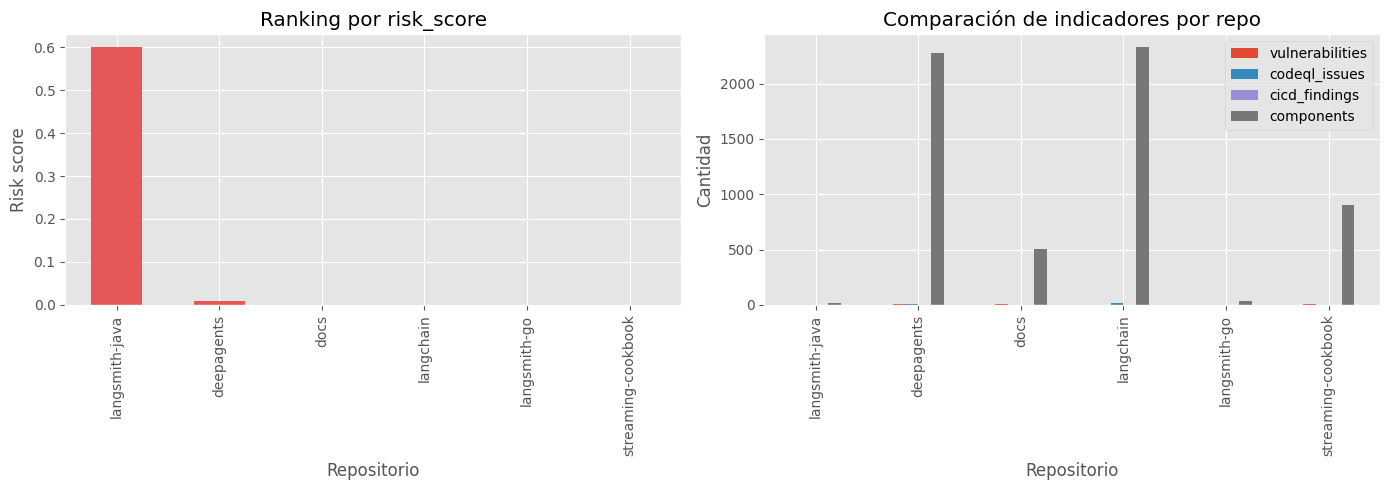

In [6]:
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if not df_repo.empty:
    df_repo.plot.bar(x='name', y='risk_score', ax=axes[0], legend=False, color='#E45756')
    df_repo.set_index('name')[['vulnerabilities', 'codeql_issues', 'cicd_findings', 'components']].plot(kind='bar', ax=axes[1])
else:
    axes[0].text(0.5, 0.5, 'Sin datos', ha='center', va='center')
    axes[1].text(0.5, 0.5, 'Sin datos', ha='center', va='center')

axes[0].set_title('Ranking por risk_score')
axes[0].set_xlabel('Repositorio')
axes[0].set_ylabel('Risk score')
axes[1].set_title('Comparación de indicadores por repo')
axes[1].set_xlabel('Repositorio')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

## Hallazgos CI/CD

### Cómo interpretar esta sección
Los hallazgos CI/CD no reemplazan escaneo de dependencias o código: agregan contexto operacional (secretos, permisos, acciones inseguras, etc.).

### Por qué importa en ciberseguridad
Un pipeline inseguro puede amplificar impacto incluso cuando el código de aplicación no presenta el mayor número de issues.


In [7]:
df_cicd

,repo,workflow,issue
0,deepagents,evals.yml,Permiso 'contents: write' innecesario
1,deepagents,release_please_parse_check.yml,Job 'parse-check': usa 'npm install' en vez de...
2,langchain,_refresh_model_profiles.yml,Permiso 'contents: write' innecesario
3,langchain,refresh_model_profiles.yml,Permiso 'contents: write' innecesario


In [8]:
# Conclusiones dinámicas
severity_order = ['Critical', 'High', 'Medium', 'Low', 'Unknown']
severity_totals = {level: 0 for level in severity_order}

for repo in analysis.get('repositories', []) or []:
    by_sev = repo.get('vulnerabilities', {}).get('by_severity', {}) or {}
    for level in severity_order:
        try:
            severity_totals[level] += int(by_sev.get(level, 0) or 0)
        except (TypeError, ValueError):
            pass

top_repo = 'N/A'
top_risk = 0.0
if not df_repo.empty:
    top_repo = str(df_repo.iloc[0].get('name', 'N/A'))
    top_risk = float(df_repo.iloc[0].get('risk_score', 0.0) or 0.0)

most_common_severity = max(severity_totals, key=severity_totals.get) if severity_totals else 'Unknown'
total_high_critical = severity_totals.get('High', 0) + severity_totals.get('Critical', 0)
total_cicd = int(df_repo['cicd_findings'].sum()) if 'cicd_findings' in df_repo else 0

cwe_ranking = analysis.get('cross_repo_analysis', {}).get('common_weakness_ranking', []) or []
common_cwe = cwe_ranking[0]['cwe'] if cwe_ranking else 'N/A'

rule_counts = {}
for repo in analysis.get('repositories', []) or []:
    for rule_id, count in (repo.get('codeql', {}).get('by_rule', {}) or {}).items():
        try:
            rule_counts[rule_id] = rule_counts.get(rule_id, 0) + int(count or 0)
        except (TypeError, ValueError):
            continue
common_rule = max(rule_counts, key=rule_counts.get) if rule_counts else 'N/A'

print('Conclusiones dinámicas (riesgo y cierre):')
print(f'- Repo con mayor riesgo: {top_repo} ({top_risk:.2f})')
print(f'- Severidad predominante: {most_common_severity}')
print(f'- Total High/Critical: {total_high_critical}')
print(f'- Total hallazgos CI/CD: {total_cicd}')
print(f'- CWE más común: {common_cwe}')
print(f'- Regla CodeQL más común: {common_rule}')

Conclusiones dinámicas (riesgo y cierre):
- Repo con mayor riesgo: langsmith-java (0.60)
- Severidad predominante: Medium
- Total High/Critical: 6
- Total hallazgos CI/CD: 4
- CWE más común: CWE-200
- Regla CodeQL más común: py/clear-text-logging-sensitive-data


## Limitaciones técnicas

- **CodeQL**: cobertura dependiente de build/autobuild y lenguajes del repositorio.
- **Syft/Grype**: la calidad del inventario depende de manifests y lockfiles presentes.
- **CI/CD**: visibilidad limitada a workflows detectables en el momento del análisis.
- **Temporalidad**: los resultados reflejan un corte puntual; cambian con nuevas versiones y commits.

## Recomendaciones
- Priorizar mitigación combinando severidad, frecuencia y capacidad de fix.
- Tratar patrones repetidos como deuda transversal (no solo local).
- Repetir ejecución periódica para seguimiento de tendencia.
- Usar `analysis.json` como fuente única para tableros y reporting.

## Conclusión final
Este cierre integra evidencia de dependencias, código y operación para construir una priorización defendible. El ranking por riesgo orienta dónde actuar primero y `analysis.json` habilita trazabilidad y comunicación consistente para informe o presentación ejecutiva.
